<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/BCNN%201K/BNN_ECG_Interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from re import X
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks



In [2]:
%pip install pyro-ppl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 19.1 MB/s eta 0:00:00


In [162]:
import math
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal, AutoNormal, AutoDelta, AutoLowRankMultivariateNormal
from pyro.nn import PyroModule, PyroSample
from pyro.optim import Adam

try:
    from torchvision import datasets, transforms
    TORCHVISION_AVAILABLE = True
except Exception as e:
    TORCHVISION_AVAILABLE = False
    print("torchvision could not be imported:", e)

In [5]:
from pyro.infer import Predictive
from bayesian_ecg_interpretability import (
    draw_posterior_samples_from_guide,
    bayesian_integrated_gradients,
    confidence_weighted_attribution,
    plot_ecg_with_attribution,
)


In [6]:
def set_seed(seed=0):
    """Set random seeds for reproducible examples."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
pyro.set_rng_seed(42)
pyro.clear_param_store()

# Use a GPU if one is available. Otherwise, use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [134]:

ECG_data_1K = np.load('ECG_waveforms_5K.npy',allow_pickle=True)
# ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')



In [176]:
labels = Echo_5K['shd_moderate_or_greater_flag']

#initial definitions
negative = labels==0
positive = labels==1
y_ts = np.array(labels[:1000])
X = ECG_data_1K
X_ts = np.swapaxes(X, 1, 2)
X_ts = X_ts[0:1000,:,]
print(X_ts.shape)
print(y_ts.shape)


print(np.bincount(y_ts))
print("Majority-class baseline:", max(np.bincount(y_ts)) / len(y_ts))

(1000, 12, 2500)
(1000,)
[477 523]
Majority-class baseline: 0.523


In [213]:
#train & test
X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long)

ts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size
batch = next(iter(ts_train_loader))
print(batch[0].shape)

ts_test_loader = DataLoader(ts_test_dataset, batch_size=32, shuffle=False)

print("Time-series training samples:", len(ts_train_dataset))
print("Time-series test samples:", len(ts_test_dataset))


torch.Size([32, 12, 2500])
Time-series training samples: 800
Time-series test samples: 200


In [230]:
class BayesianSmallCNN(PyroModule):
    def __init__(self, prior_scale=0.1, pooled_len=1):
        super().__init__()
        self.pooled_len = pooled_len
        self.prior_scale = prior_scale

        # Keeps sampled priors on the same device as the model.
        self.register_buffer("_device_anchor", torch.tensor(0.0))

        def make_prior(shape):
            def prior(_module):
                device = self._device_anchor.device
                loc = torch.tensor(0.0, device=device)
                scale = torch.tensor(prior_scale, device=device)
                return dist.Normal(loc, scale).expand(shape).to_event(len(shape))
            return prior

        # ============================================================
        #   conv1_out = number of filters in the first convolution
        #   conv1_k   = kernel size for the first convolution
        #   conv1_pad = padding for the first convolution
        # ============================================================
        conv1_out = 10
        conv1_k = 51
        conv1_pad = 1

        # ============================================================
        #   hidden_out = number of filters in conv2-conv10
        #   hidden_k   = kernel size in conv2-conv10
        #   hidden_pad  = padding in conv2-conv10
        # ============================================================
        hidden_out = 20
        hidden_k = 31
        hidden_pad = 1

        def make_bayesian_conv(in_ch, out_ch, kernel_size, padding):
            layer = PyroModule[nn.Conv1d](in_ch, out_ch, kernel_size=kernel_size, padding=padding)
            layer.weight = PyroSample(make_prior([out_ch, in_ch, kernel_size]))
            layer.bias = PyroSample(make_prior([out_ch]))
            return layer

        self.conv1 = make_bayesian_conv(12, conv1_out, conv1_k, conv1_pad)
        self.conv2 = make_bayesian_conv(conv1_out, hidden_out, hidden_k, hidden_pad)
        self.conv3 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)
        self.conv4 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)
        self.conv5 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)
        # self.conv6 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)
        # self.conv7 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)

        # self.conv8 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)
        # self.conv9 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)
        # self.conv10 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)

        self.bn1 = nn.BatchNorm1d(conv1_out)
        self.bn2 = nn.BatchNorm1d(hidden_out)
        self.bn3 = nn.BatchNorm1d(hidden_out)
        self.bn4 = nn.BatchNorm1d(hidden_out)
        self.bn5 = nn.BatchNorm1d(hidden_out)
        # self.bn6 = nn.BatchNorm1d(hidden_out)
        # self.bn7 = nn.BatchNorm1d(hidden_out)

        # self.bn8 = nn.BatchNorm1d(hidden_out)
        # self.bn9 = nn.BatchNorm1d(hidden_out)
        # self.bn10 = nn.BatchNorm1d(hidden_out)

        self.fc1 = PyroModule[nn.Linear](hidden_out, 32)
        self.fc1.weight = PyroSample(make_prior([32, hidden_out]))
        self.fc1.bias = PyroSample(make_prior([32]))

        self.fc2 = PyroModule[nn.Linear](32, 2)
        self.fc2.weight = PyroSample(make_prior([2, 32]))
        self.fc2.bias = PyroSample(make_prior([2]))

    def forward(self, x, y=None, dataset_size=None):
        x = x.to(self._device_anchor.device)
        if y is not None:
            y = y.to(self._device_anchor.device)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn4(self.conv4(x)))
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.max_pool1d(x, kernel_size=2)

        # x = F.relu(self.bn6(self.conv6(x)))
        # x = F.max_pool1d(x, kernel_size=2)

        # x = F.relu(self.bn7(self.conv7(x)))
        # x = F.max_pool1d(x, kernel_size=2)

        # x = F.relu(self.bn8(self.conv8(x)))
        # x = F.max_pool1d(x, kernel_size=2)

        # x = F.relu(self.bn9(self.conv9(x)))
        # x = F.max_pool1d(x, kernel_size=2)

        # x = F.relu(self.bn10(self.conv10(x)))

        x = F.adaptive_avg_pool1d(x, 1)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)

        if y is not None and dataset_size is not None:
            scale = dataset_size / x.shape[0]
        else:
            scale = 1.0

        with pyro.plate("data", x.shape[0]):
            with pyro.poutine.scale(scale=scale):
                pyro.sample("obs", dist.Categorical(logits=logits), obs=y)

        return logits

In [231]:
pyro.clear_param_store()
set_seed(42)

bcnn = BayesianSmallCNN(prior_scale=1.0).to(device)
# bcnn_guide = AutoDiagonalNormal(bcnn)
bcnn_guide = AutoLowRankMultivariateNormal(bcnn)



bcnn_optimizer = Adam({"lr": 1e-3, "betas": (0.9, 0.999)})
bcnn_svi = SVI(
    model=bcnn,
    guide=bcnn_guide,
    optim=bcnn_optimizer,
    loss=Trace_ELBO(num_particles=6),
)

In [232]:
def train_one_epoch_svi(svi, data_loader, device, dataset_size, max_batches=None):
    total_loss = 0.0
    total_examples = 0

    for batch_idx, (x, y) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        loss = svi.step(x, y, dataset_size)
        total_loss += loss
        total_examples += x.shape[0]

    return total_loss / max(1, total_examples)

@torch.no_grad()
def predict_proba_bayesian(model, guide, x, num_samples=2500):
    """Average class probabilities over posterior samples of the network."""
    predictive = Predictive(
        model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("_RETURN",),
    )
    out = predictive(x, None)

    # Shape is usually [num_samples, batch_size, num_classes].
    logits_samples = out["_RETURN"]
    probs_samples = torch.softmax(logits_samples, dim=-1)
    mean_probs = probs_samples.mean(dim=0)
    return mean_probs


@torch.no_grad()
def evaluate_bayesian_classifier(model, guide, data_loader, device, num_samples=2500, max_batches=None):
    """Evaluate posterior-averaged classification accuracy."""
    correct = 0
    total = 0

    for batch_idx, (x, y) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)
        mean_probs = predict_proba_bayesian(model, guide, x, num_samples=num_samples)
        preds = mean_probs.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()

    return correct / max(1, total)

In [233]:
num_epochs = 50
max_batches_per_epoch = None
num_prediction_samples = 50

bcnn_losses = []

for epoch in range(num_epochs):
    avg_loss = train_one_epoch_svi(
        bcnn_svi,
        ts_train_loader,
        device,
        dataset_size=train_size,
        max_batches=max_batches_per_epoch,
    )
    bcnn_losses.append(avg_loss)

    test_acc = evaluate_bayesian_classifier(
        bcnn,
        bcnn_guide,
        ts_test_loader,
        device,
        num_samples=num_prediction_samples,
        max_batches=2,
    )

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"avg negative ELBO per example = {avg_loss:.2f} | "
        f"approx test accuracy = {test_acc:.3f}"
    )

plt.figure(figsize=(7, 4))
plt.plot(bcnn_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average negative ELBO per example")
plt.title("Bayesian CNN Training Loss")
plt.grid(True)
plt.show()

# train_acc = evaluate_bayesian_classifier(
#     bcnn,
#     bcnn_guide,
#     ts_train_loader,
#     device,
#     num_samples=200
# )

# test_acc = evaluate_bayesian_classifier(
#     bcnn,
#     bcnn_guide,
#     ts_test_loader,
#     device,
#     num_samples=200
# )

# print("Train accuracy:", train_acc)
# print("Test accuracy:", test_acc)

Epoch  1/50 | avg negative ELBO per example = 3453.69 | approx test accuracy = 0.656
Epoch  2/50 | avg negative ELBO per example = 3409.30 | approx test accuracy = 0.766
Epoch  3/50 | avg negative ELBO per example = 3367.07 | approx test accuracy = 0.734
Epoch  4/50 | avg negative ELBO per example = 3326.21 | approx test accuracy = 0.766
Epoch  5/50 | avg negative ELBO per example = 3285.66 | approx test accuracy = 0.719
Epoch  6/50 | avg negative ELBO per example = 3245.01 | approx test accuracy = 0.750
Epoch  7/50 | avg negative ELBO per example = 3204.31 | approx test accuracy = 0.766
Epoch  8/50 | avg negative ELBO per example = 3164.50 | approx test accuracy = 0.719
Epoch  9/50 | avg negative ELBO per example = 3125.28 | approx test accuracy = 0.750


KeyboardInterrupt: 

In [218]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

@torch.no_grad()
def get_predictions(model, guide, data_loader, device, num_samples=250):
    all_preds = []
    all_labels = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        mean_probs = predict_proba_bayesian(
            model, guide, x, num_samples=num_samples
        )
        preds = mean_probs.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(
    bcnn,
    bcnn_guide,
    ts_test_loader,
    device,
    num_samples=250
)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[77 23]
 [26 74]]
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       100
           1       0.76      0.74      0.75       100

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.75       200
weighted avg       0.76      0.76      0.75       200



In [130]:
x_batch, y_batch = next(iter(ts_test_loader))

print(x_batch.shape)  # e.g. (batch_size, 12, n_timepoints)
print(y_batch.shape)

torch.Size([32, 12, 2500])
torch.Size([32])


In [131]:
from pyro.infer import Predictive
predictive = Predictive(
    model=bcnn,
    guide=bcnn_guide,
    num_samples=50,
    return_sites=("logits", "_RETURN"),
)

In [132]:
bcnn.eval()

x_batch = x_batch.to(bcnn._device_anchor.device)

posterior_samples = draw_posterior_samples_from_guide(
    guide=bcnn_guide,
    x=x_batch,
    num_samples=100,
)

attr_mean, attr_std = bayesian_integrated_gradients(
    model=bcnn,
    posterior_samples=posterior_samples,
    x=x_batch,
    steps=32,
)

stable_attr = confidence_weighted_attribution(attr_mean, attr_std)


KeyboardInterrupt: 

In [113]:
from bayesian_ecg_interpretability import aggregate_attribution_windows, top_ecg_regions


window_scores = aggregate_attribution_windows(
    attr_mean,
    window_size=100,
    stride=150,
)

regions = top_ecg_regions(
    window_scores,
    top_k=10,
    sampling_rate=250,
    sample_idx=4,
)

for r in regions:
    print(r)

print(y_batch[4])

{'lead': 'V2', 'start_sec': 0.3, 'end_sec': 0.7, 'score': 0.13479670882225037}
{'lead': 'V2', 'start_sec': 1.5, 'end_sec': 1.9, 'score': 0.1317053735256195}
{'lead': 'V2', 'start_sec': 1.2, 'end_sec': 1.6, 'score': 0.11795797199010849}
{'lead': 'V3', 'start_sec': 0.3, 'end_sec': 0.7, 'score': 0.11751560121774673}
{'lead': 'V2', 'start_sec': 0.6, 'end_sec': 1.0, 'score': 0.11150165647268295}
{'lead': 'V3', 'start_sec': 1.5, 'end_sec': 1.9, 'score': 0.11149781197309494}
{'lead': 'V4', 'start_sec': 0.3, 'end_sec': 0.7, 'score': 0.10989190638065338}
{'lead': 'aVR', 'start_sec': 0.3, 'end_sec': 0.7, 'score': 0.10829466581344604}
{'lead': 'aVR', 'start_sec': 1.5, 'end_sec': 1.9, 'score': 0.10744430124759674}
{'lead': 'V4', 'start_sec': 1.5, 'end_sec': 1.9, 'score': 0.10614897310733795}
tensor(0)


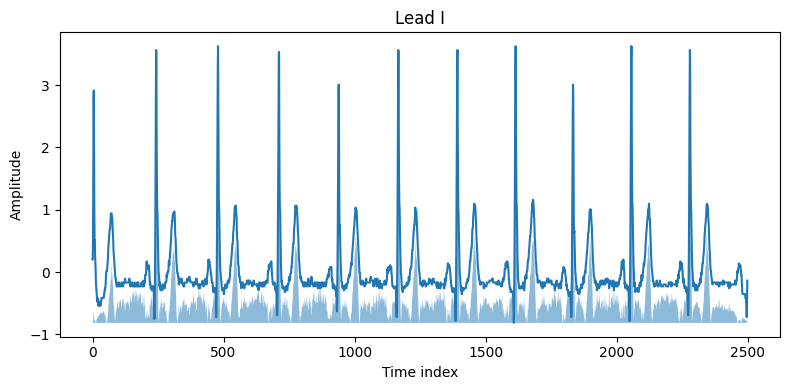

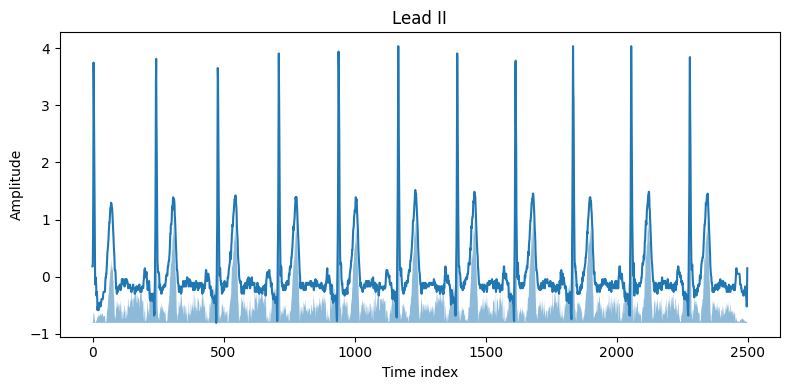

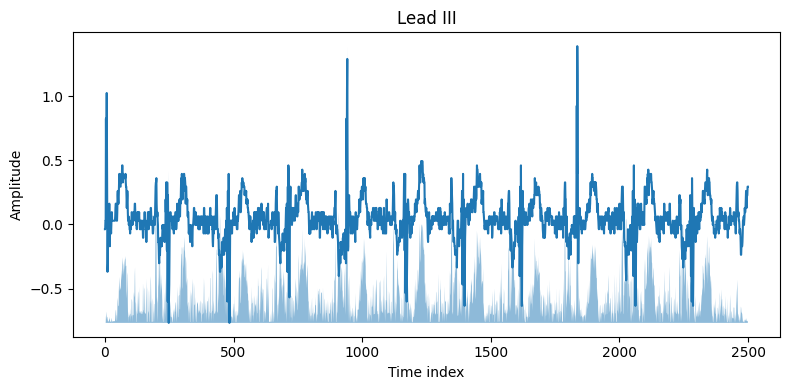

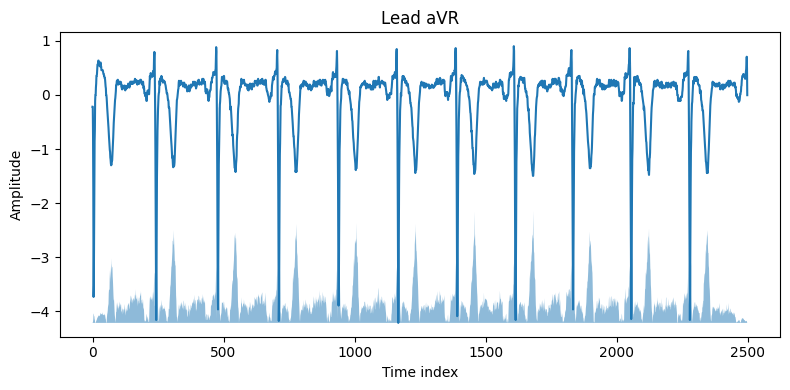

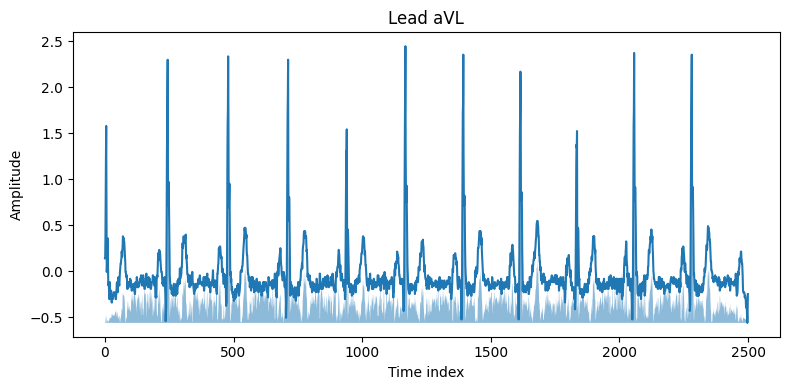

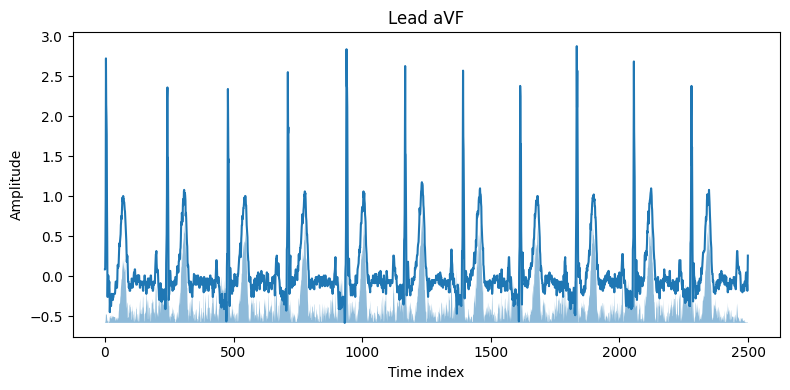

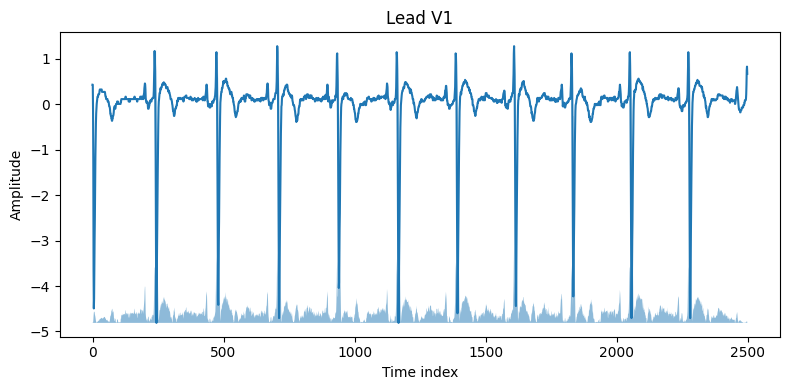

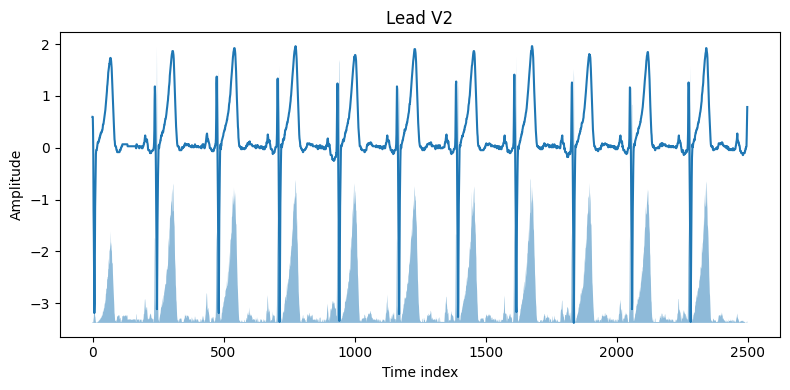

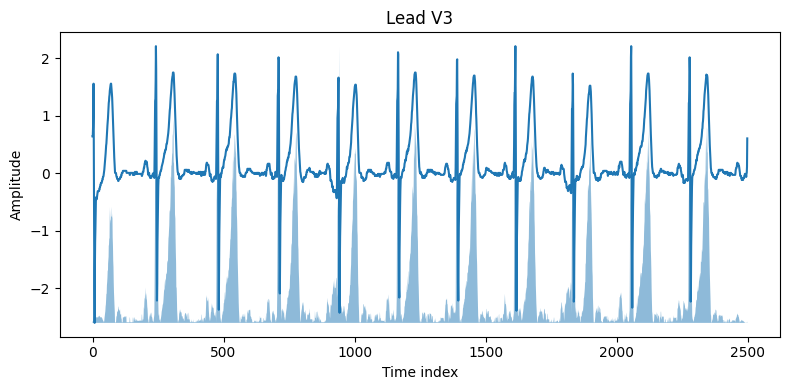

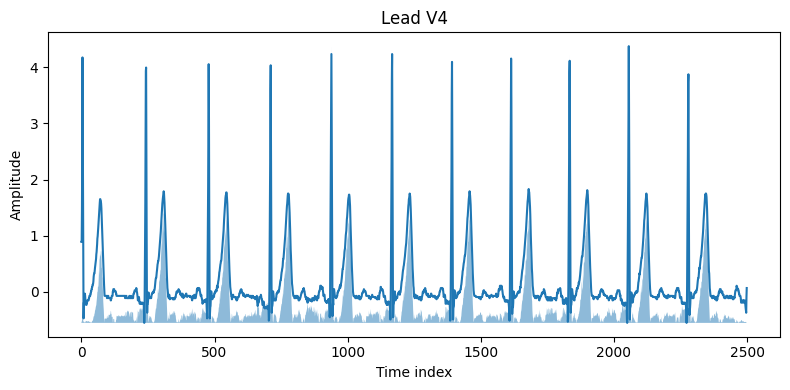

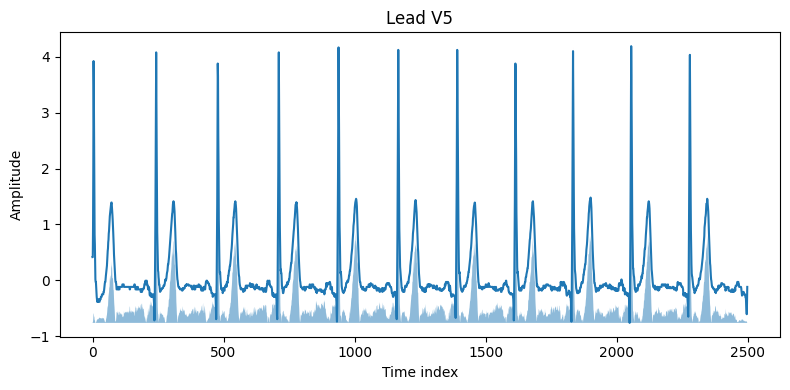

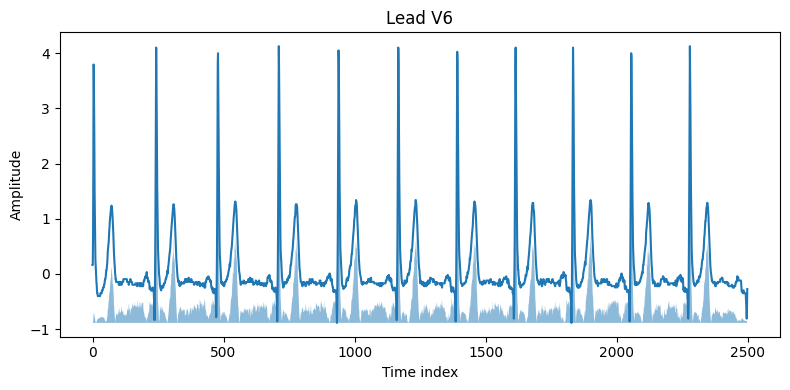

[<Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>,
 <Figure size 800x400 with 1 Axes>]

In [114]:
plot_ecg_with_attribution(x_batch, attr_mean, sample_idx=4,show=True,figsize=(8,4),alpha=0.5)
# plot_ecg_with_attribution(x_batch, attr_std, sample_idx=0,show=True,figsize=(8,4),alpha=0.5)
# plot_ecg_with_attribution(x_batch, stable_attr, sample_idx=15,show=True,figsize=(8,4),alpha=0.5)

{'lead': 'aVL', 'start_sec': 0.5, 'end_sec': 0.9, 'score': 0.11137380450963974}
{'lead': 'III', 'start_sec': 0.5, 'end_sec': 0.9, 'score': 0.10423636436462402}
{'lead': 'aVL', 'start_sec': 0.2, 'end_sec': 0.6, 'score': 0.09656421095132828}
{'lead': 'I', 'start_sec': 0.7, 'end_sec': 1.1, 'score': 0.09289877861738205}
{'lead': 'I', 'start_sec': 0.2, 'end_sec': 0.6, 'score': 0.09116633981466293}
{'lead': 'V3', 'start_sec': 0.2, 'end_sec': 0.6, 'score': 0.08310513943433762}
{'lead': 'aVL', 'start_sec': 0.8, 'end_sec': 1.2, 'score': 0.08261196315288544}
{'lead': 'V3', 'start_sec': 0.8, 'end_sec': 1.2, 'score': 0.08227556198835373}
{'lead': 'V3', 'start_sec': 0.7, 'end_sec': 1.1, 'score': 0.08059234172105789}
{'lead': 'V5', 'start_sec': 1.5, 'end_sec': 1.9, 'score': 0.07960150390863419}
tensor(1)


[[74 26]
 [18 82]]
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.76      0.82      0.79       100

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.78      0.78       200



## Classification Metrics

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
)

## 2. Prediction objects used by the metrics

In [ ]:
def as_numpy(x):
    """Convert torch tensors or array-like objects to NumPy arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def probs_to_predictions(probs, threshold=0.5):
    """
    Convert probabilities to hard class predictions.

    Args:
        probs: Either shape [N] containing P(class 1), or shape [N, 2]
               containing [P(class 0), P(class 1)].
        threshold: Positive-class threshold used if probs has shape [N].

    Returns:
        y_pred: shape [N]
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return (probs >= threshold).astype(int)

    if probs.ndim == 2:
        return np.argmax(probs, axis=1).astype(int)

    raise ValueError("probs must have shape [N] or [N, C].")


def positive_class_probability(probs):
    """
    Extract P(class 1) from either shape [N] or shape [N, 2].
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return probs

    if probs.ndim == 2 and probs.shape[1] == 2:
        return probs[:, 1]

    raise ValueError("For binary metrics, probs must have shape [N] or [N, 2].")

## 3. Collecting predictions from a standard neural network

In [ ]:
@torch.no_grad()
def collect_predictions_standard_nn(model, data_loader, device):
    """
    Collect labels and probabilities from a standard deterministic neural network.

    Args:
        model: PyTorch classifier returning logits of shape [batch_size, 2].
        data_loader: DataLoader yielding (x, y).
        device: torch device.

    Returns:
        y_true: shape [N]
        probs: shape [N, 2]
        y_pred: shape [N]
    """
    model.eval()

    all_y = []
    all_probs = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        probs = F.softmax(logits, dim=-1)

        all_y.append(y.detach().cpu())
        all_probs.append(probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 4. Collecting predictions from a Bayesian neural network

In [ ]:
@torch.no_grad()
def collect_predictions_bayesian_nn(model, guide, data_loader, device, num_samples=200):
    """
    Collect labels and posterior predictive probabilities from a Bayesian neural network.

    This assumes a helper function exists:
        predict_proba_bayesian(model, guide, x, num_samples)

    Args:
        model: PyroModule Bayesian classifier.
        guide: Pyro guide, such as AutoDiagonalNormal(model).
        data_loader: DataLoader yielding (x, y).
        device: torch device.
        num_samples: Number of posterior samples used for prediction.

    Returns:
        y_true: shape [N]
        probs: shape [N, 2]
        y_pred: shape [N]
    """
    model.eval()

    all_y = []
    all_probs = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        mean_probs = predict_proba_bayesian(
            model=model,
            guide=guide,
            x=x,
            num_samples=num_samples,
        )

        all_y.append(y.detach().cpu())
        all_probs.append(mean_probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 5. Confusion matrix quantities

In [ ]:
def confusion_counts(y_true, y_pred):
    """
    Return TN, FP, FN, TP for binary labels 0 and 1.
    """
    y_true = as_numpy(y_true).astype(int)
    y_pred = as_numpy(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp

## 6. Accuracy

In [ ]:
def compute_accuracy(y_true, y_pred):
    y_true = as_numpy(y_true)
    y_pred = as_numpy(y_pred)
    return np.mean(y_true == y_pred)

## 7. Sensitivity and specificity

In [ ]:
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sensitivity, specificity

## 8. Balanced accuracy

In [ ]:
def compute_balanced_accuracy(y_true, y_pred):
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)
    return 0.5 * (sensitivity + specificity)

## 9. AUROC

In [ ]:
def compute_auroc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, p1)


def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("ROC curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. AUPRC

In [ ]:
def compute_auprc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, p1)


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Negative log likelihood

In [ ]:
def compute_negative_log_likelihood(y_true, probs, eps=1e-12):
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        p1 = np.clip(probs, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))

    if probs.ndim == 2:
        probs = np.clip(probs, eps, 1.0)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return log_loss(y_true, probs, labels=[0, 1])

    raise ValueError("probs must have shape [N] or [N, 2].")

## 12. Brier score

In [ ]:
def compute_brier_score(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)
    return np.mean((p1 - y_true) ** 2)

## 13. Expected calibration error

In [ ]:
def compute_expected_calibration_error(y_true, probs, n_bins=10):
    """
    Confidence-based ECE for binary or multiclass probabilities.

    Args:
        y_true: shape [N]
        probs: shape [N, C] or shape [N] for binary P(class 1)
        n_bins: number of confidence bins

    Returns:
        ece: scalar
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        prop = np.mean(in_bin)

        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidence[in_bin])
            ece += prop * abs(acc_bin - conf_bin)

    return ece


def calibration_table(y_true, probs, n_bins=10):
    """
    Return bin-level calibration information.
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        n_bin = int(np.sum(in_bin))

        if n_bin > 0:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": n_bin,
                "mean_confidence": float(np.mean(confidence[in_bin])),
                "empirical_accuracy": float(np.mean(correct[in_bin])),
                "abs_gap": float(abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))),
            })
        else:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "empirical_accuracy": np.nan,
                "abs_gap": np.nan,
            })

    return pd.DataFrame(rows)


def plot_calibration_curve(y_true, probs, n_bins=10):
    table = calibration_table(y_true, probs, n_bins=n_bins)
    table_nonempty = table.dropna(subset=["mean_confidence", "empirical_accuracy"])

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(
        table_nonempty["mean_confidence"],
        table_nonempty["empirical_accuracy"],
        s=50,
        label="Observed bins",
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Calibration curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Negative ELBO

In [ ]:
def estimate_negative_elbo_per_example_pyro(model, guide, data_loader, device, dataset_size=None):
    """
    Estimate negative ELBO per example for a Pyro Bayesian neural network.

    Args:
        model: Pyro model with forward(x, y=None, dataset_size=None).
        guide: Pyro guide.
        data_loader: DataLoader yielding (x, y).
        device: torch device.
        dataset_size: Optional size used for minibatch scaling. If None, each batch
                      uses its own batch size, which is often appropriate for a
                      held-out evaluation estimate.

    Returns:
        negative_elbo_per_example: scalar float
    """
    try:
        import pyro
        from pyro.infer import Trace_ELBO
    except ImportError as exc:
        raise ImportError("This function requires Pyro. Install pyro-ppl first.") from exc

    model.eval()
    elbo = Trace_ELBO()

    total_loss = 0.0
    total_examples = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        batch_size = x.shape[0]
        ds = dataset_size if dataset_size is not None else batch_size

        loss = elbo.differentiable_loss(model, guide, x, y, ds)

        total_loss += float(loss.detach().cpu())
        total_examples += batch_size

    return total_loss / max(total_examples, 1)


def estimate_cross_entropy_per_example_standard_nn(model, data_loader, device):
    """
    Estimate cross-entropy/NLL per example for a standard neural network.
    This is the standard deterministic analogue of the likelihood part of ELBO.
    """
    model.eval()

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.detach().cpu())
            total_examples += x.shape[0]

    return total_loss / max(total_examples, 1)

## 15. One function to calculate all non-ELBO metrics

In [ ]:
def calculate_binary_classification_metrics(y_true, probs, threshold=0.5, n_bins=10):
    """
    Calculate binary classification metrics from labels and probabilities.

    Args:
        y_true: shape [N], labels 0/1.
        probs: shape [N] containing P(class 1), or shape [N, 2].
        threshold: threshold for P(class 1), used only if probs has shape [N].
        n_bins: number of bins for ECE.

    Returns:
        metrics: dictionary
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        y_pred = probs_to_predictions(probs, threshold=threshold)
        p1 = probs
        probs_2d = np.column_stack([1.0 - p1, p1])
    else:
        y_pred = probs.argmax(axis=1)
        p1 = probs[:, 1]
        probs_2d = probs

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)

    metrics = {
        "accuracy": compute_accuracy(y_true, y_pred),
        "balanced_accuracy": compute_balanced_accuracy(y_true, y_pred),
        "auroc": compute_auroc(y_true, probs_2d),
        "auprc": compute_auprc(y_true, probs_2d),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "negative_log_likelihood": compute_negative_log_likelihood(y_true, probs_2d),
        "brier_score": compute_brier_score(y_true, probs_2d),
        "expected_calibration_error": compute_expected_calibration_error(y_true, probs_2d, n_bins=n_bins),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "positive_prevalence": float(np.mean(y_true == 1)),
    }

    return metrics

## 16. Wrapper for a standard neural network classifier (use later)

In [ ]:
def evaluate_standard_nn_classifier(model, data_loader, device, n_bins=10):
    y_true, probs, y_pred = collect_predictions_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["cross_entropy_per_example"] = estimate_cross_entropy_per_example_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    return metrics, y_true, probs, y_pred

## 17. Wrapper for a Bayesian neural network classifier


In [ ]:
def evaluate_bayesian_nn_classifier(model, guide, data_loader, device, num_samples=100, n_bins=10, dataset_size=None):
    y_true, probs, y_pred = collect_predictions_bayesian_nn(
        model=model,
        guide=guide,
        data_loader=data_loader,
        device=device,
        num_samples=num_samples,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["negative_elbo_per_example"] = estimate_negative_elbo_per_example_pyro(
        model=model,
        guide=guide,
        data_loader=data_loader,
        device=device,
        dataset_size=dataset_size,
    )

    metrics["num_posterior_prediction_samples"] = num_samples

    return metrics, y_true, probs, y_pred

## 18. Demonstration with synthetic predictions

In [ ]:
y_true_test, probs, y_pred = collect_predictions_bayesian_nn(
    model=bcnn,
    guide=bcnn_guide,
    data_loader=ts_test_loader,
    device=device
)


metrics_demo = calculate_binary_classification_metrics(
    y_true=y_true_test,
    probs=probs,
    n_bins=10,
)

pd.DataFrame([metrics_demo]).T.rename(columns={0: "value"})

,value
accuracy,0.512500
balanced_accuracy,0.508073
auroc,0.791255
auprc,0.799011
sensitivity,1.000000
specificity,0.016145
negative_log_likelihood,0.663904
brier_score,0.237773
expected_calibration_error,0.188699
tn,16.000000


Confusion matrix [[TN, FP], [FN, TP]]:
[[  16  975]
 [   0 1009]]


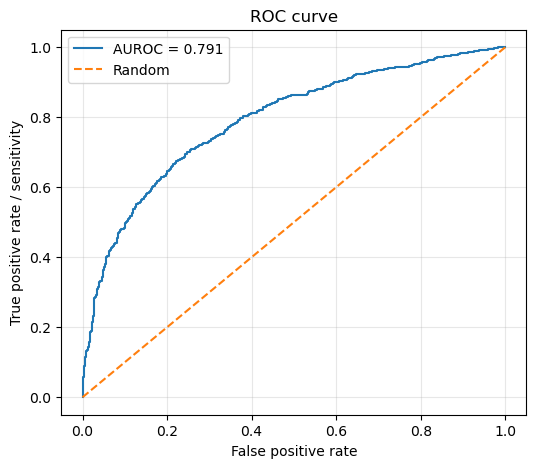

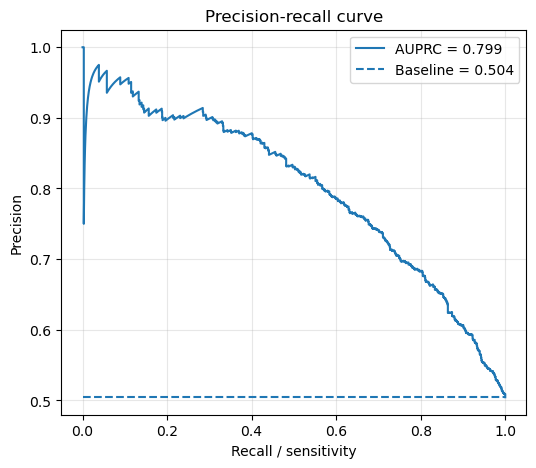

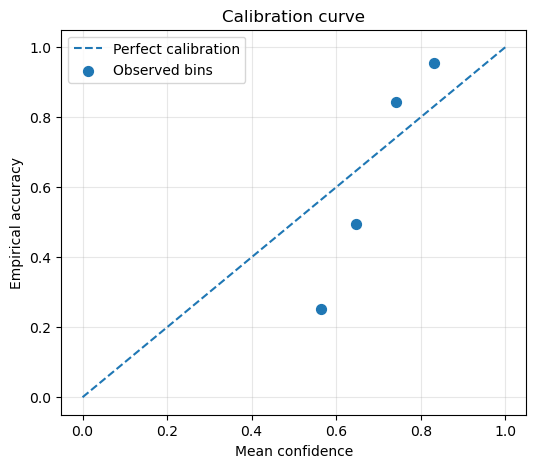

,bin,confidence_lower,confidence_upper,n,mean_confidence,empirical_accuracy,abs_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,0,NaN,NaN,NaN
3,4,0.3,0.4,0,NaN,NaN,NaN
4,5,0.4,0.5,0,NaN,NaN,NaN
5,6,0.5,0.6,608,0.563952,0.251645,0.312307
6,7,0.6,0.7,895,0.645860,0.494972,0.150888
7,8,0.7,0.8,406,0.741134,0.842365,0.101230
8,9,0.8,0.9,91,0.831072,0.956044,0.124972
9,10,0.9,1.0,0,NaN,NaN,NaN


In [ ]:
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_true_test, y_pred, labels=[0, 1]))

plot_roc_curve(y_true_test, probs)
plot_precision_recall_curve(y_true_test, probs)
plot_calibration_curve(y_true_test, probs, n_bins=10)
calibration_table(y_true_test, probs, n_bins=10)


## 19. How to use this with your ECG standard neural network

If you have a standard PyTorch CNN called `standard_cnn`, use:

```python
standard_metrics, standard_y, standard_probs, standard_pred = evaluate_standard_nn_classifier(
    model=standard_cnn,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

pd.DataFrame([standard_metrics], index=["standard CNN"])
```

The model must return logits of shape `[batch_size, 2]`.

## 20. How to use this with your ECG Bayesian neural network

If you have a Bayesian CNN called `bcnn` and guide called `bcnn_guide`, use:

```python
bayes_metrics, bayes_y, bayes_probs, bayes_pred = evaluate_bayesian_nn_classifier(
    model=bcnn,
    guide=bcnn_guide,
    data_loader=ts_test_loader,
    device=device,
    num_samples=100,
    n_bins=10,
    dataset_size=None,
)

pd.DataFrame([bayes_metrics], index=["Bayesian CNN"])
```

For training ELBO during minibatch training, `dataset_size` should usually be the full training-set size:

```python
train_dataset_size = len(ts_train_loader.dataset)
```

For held-out test-set reporting, using `dataset_size=None` gives an evaluation-style per-example estimate on the batches being evaluated.

## 21. Comparing a standard classifier and Bayesian classifier

Once both models have been evaluated, compare them side-by-side:

```python
comparison = pd.DataFrame(
    [standard_metrics, bayes_metrics],
    index=["standard CNN", "Bayesian CNN"],
)

comparison.T
```

Interpretation guidance:

| Metric | Better direction | What it emphasizes |
|---|---:|---|
| negative ELBO | lower | Bayesian posterior fit plus prior regularization |
| accuracy | higher | Overall hard-decision correctness |
| balanced accuracy | higher | Average performance across positive and negative classes |
| AUROC | higher | Ranking positives above negatives |
| AUPRC | higher | Positive-class retrieval, especially with imbalance |
| sensitivity | higher | Avoiding false negatives |
| specificity | higher | Avoiding false positives |
| negative log likelihood | lower | Probabilistic correctness; punishes confident errors |
| Brier score | lower | Mean squared probability error |
| expected calibration error | lower | Agreement between confidence and empirical accuracy |

For a medical classifier, raw accuracy is rarely enough. A Bayesian classifier may have similar accuracy to a standard classifier but better NLL, Brier score, ECE, or uncertainty behavior. That can still be valuable if uncertainty is clinically important.

## 22. Practical notes for Bayesian classifiers

### Use enough posterior samples

Bayesian predictions can be noisy if `num_samples` is small. For final evaluation, try values such as:

```python
num_samples = 100
num_samples = 250
num_samples = 500
```

and check whether the metrics stabilize.

### Calculate metrics from averaged probabilities

For Bayesian classifiers, do not calculate metrics from a single sampled network unless you specifically want to analyze one posterior draw. Usually, use:

$$
\bar p_i = \frac{1}{S}\sum_{s=1}^S p(y_i=1 \mid x_i, \theta^{(s)}).
$$

Then calculate accuracy, AUROC, AUPRC, NLL, Brier score, and ECE from \(\bar p_i\).

### Do not expect ELBO and accuracy to move identically

Negative ELBO optimizes probabilistic fit plus a KL penalty. Accuracy is a thresholded hard-decision metric. They are related but not equivalent.

### Report class prevalence

AUPRC and accuracy are easier to interpret when you also report:

$$
P(y=1).
$$

This notebook includes `positive_prevalence` in the metrics dictionary.